# AI, Machine Learning and NLP

A model report answers the same handful of questions in the same order: did the run converge, which settings won, what does the model get wrong, can its confidence be trusted, how does it compare with what others have published, and what is in the data behind it. This page walks one story through those questions and names the figure that answers each, so the chart to reach for comes with the question rather than the other way round. Every figure links to the chart guide that covers it in full.

The story is a six-class support ticket classifier: a small encoder fine-tuned to route tickets into `Billing`, `Refunds`, `Shipping`, `Account`, `Technical`, and `Feedback`. Its training log, its held-out predictions, and its corpus are **simulated** — one seeded numpy draw in a hidden cell, so every docs build produces the same figures. The model comparison is the exception: those figures use published benchmark numbers, with the source named where they appear.

In [1]:
from datachart.charts import (
    BarChart,
    BumpChart,
    DumbbellChart,
    Heatmap,
    Histogram,
    LineChart,
    ParallelCoords,
    RidgelinePlot,
    SankeyChart,
    ScatterChart,
)
from datachart.constants import ASPECT_RATIO, FIG_SIZE, VALUE_FORMAT
from datachart.utils import Grid, Panel

The hidden cell below holds the whole simulation: `train_loss` and `valid_loss` as one row per seed, `learning_rate` for the schedule, the 24 sweep trials, the held-out labels `y_true` with each model's predictions and probabilities, and the corpus samples. The sections that follow only reshape those arrays into the records the charts take.

In [2]:
import numpy as np

# Every number below is simulated: one illustrative run of a six-class support
# ticket classifier, seeded so every docs build draws the same figures.
rng = np.random.default_rng(20260921)

CLASSES = ["Billing", "Refunds", "Shipping", "Account", "Technical", "Feedback"]
SPLITS = ["Train", "Validation", "Test"]
SEEDS = 5

# --- training: the loss of five seeds over 3000 steps, warmup then cosine ---
STEPS = np.arange(0, 3001, 100)
WARMUP_STEPS = 300
PEAK_LR = 3e-4
after_warmup = np.clip((STEPS - WARMUP_STEPS) / (STEPS[-1] - WARMUP_STEPS), 0, 1)


def _loss(floor, scale, noise, drift=0.0):
    base = floor + scale * np.exp(-3.1 * after_warmup) + drift * after_warmup**3
    return base + rng.normal(0, noise, size=(SEEDS, STEPS.size)) * (0.4 + after_warmup)


train_loss = _loss(0.21, 1.72, 0.030)
valid_loss = _loss(0.38, 1.55, 0.045, drift=0.13)
learning_rate = (
    PEAK_LR * np.minimum(STEPS / WARMUP_STEPS, 1.0) * 0.5 * (1 + np.cos(np.pi * after_warmup))
)

# --- the sweep: 24 trials of a random search over four settings ---
N_TRIALS = 24
log_lr = rng.uniform(-5.0, -3.0, N_TRIALS)
warmup_ratio = rng.choice([0.0, 0.03, 0.06, 0.1], N_TRIALS)
dropout = rng.choice([0.0, 0.1, 0.2, 0.3], N_TRIALS)
batch_size = rng.choice([8, 16, 32, 64], N_TRIALS)
sweep_f1 = (
    0.86
    - 0.32 * (log_lr + 4.1) ** 2
    - 0.55 * (dropout - 0.15) ** 2
    - 0.25 * (warmup_ratio - 0.06) ** 2
    - 0.0006 * (batch_size - 16)
    + rng.normal(0, 0.012, N_TRIALS)
)

# --- the held-out predictions of two models on 2400 tickets ---
N_HELD_OUT = 2400
PRIORS = np.array([0.24, 0.13, 0.21, 0.15, 0.19, 0.08])
SIBLING = {0: 1, 1: 0}  # Billing and Refunds share most of their vocabulary
REPORTED_TEMPERATURE = 0.35  # the head is uncalibrated: it sharpens its scores

y_true = rng.choice(len(CLASSES), size=N_HELD_OUT, p=PRIORS)
_rows = np.arange(N_HELD_OUT)


def _predict(margins, sibling_pull):
    logits = rng.normal(0, 1, size=(N_HELD_OUT, len(CLASSES)))
    logits[_rows, y_true] += np.asarray(margins)[y_true]
    for cls, sibling in SIBLING.items():
        logits[y_true == cls, sibling] += sibling_pull
    scaled = logits / REPORTED_TEMPERATURE
    scaled -= scaled.max(axis=1, keepdims=True)
    exp = np.exp(scaled)
    return logits.argmax(axis=1), exp / exp.sum(axis=1, keepdims=True)


baseline_pred, baseline_probs = _predict([2.6, 1.7, 2.9, 2.6, 3.0, 1.5], 1.2)
tuned_pred, tuned_probs = _predict([2.45, 2.35, 2.6, 2.3, 2.65, 2.3], 0.75)

# the confusion matrix of the fine-tuned model, as counts and as row shares
confusion_counts = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
for true_cls, pred_cls in zip(y_true, tuned_pred):
    confusion_counts[true_cls, pred_cls] += 1
confusion_share = confusion_counts / confusion_counts.sum(axis=1, keepdims=True)


def _f1_per_class(pred):
    scores = []
    for cls in range(len(CLASSES)):
        hit = np.sum((pred == cls) & (y_true == cls))
        false_pos = np.sum((pred == cls) & (y_true != cls))
        false_neg = np.sum((pred != cls) & (y_true == cls))
        scores.append(2 * hit / (2 * hit + false_pos + false_neg))
    return np.array(scores)


baseline_f1 = _f1_per_class(baseline_pred)
tuned_f1 = _f1_per_class(tuned_pred)

HARD_CLASS = 1  # Refunds: the class the two models disagree on most
is_refund = y_true == HARD_CLASS


def _roc(scores):
    order = np.argsort(-scores)
    hit = is_refund[order]
    return (
        np.concatenate([[0.0], np.cumsum(~hit) / np.sum(~hit)]),
        np.concatenate([[0.0], np.cumsum(hit) / np.sum(hit)]),
    )


def _precision_recall(scores):
    order = np.argsort(-scores)
    hit = is_refund[order]
    found = np.cumsum(hit)
    return found / hit.sum(), found / np.arange(1, hit.size + 1)


roc_baseline = _roc(baseline_probs[:, HARD_CLASS])
roc_tuned = _roc(tuned_probs[:, HARD_CLASS])
pr_baseline = _precision_recall(baseline_probs[:, HARD_CLASS])
pr_tuned = _precision_recall(tuned_probs[:, HARD_CLASS])
def _area(curve):
    """The area under a curve given as (x, y), by the trapezoid rule."""
    x, y = curve
    return float(np.sum(np.diff(x) * (y[1:] + y[:-1]) / 2))


auc_baseline = _area(roc_baseline)
auc_tuned = _area(roc_tuned)

# --- calibration: the confidence of the fine-tuned model against its accuracy
confidence = tuned_probs.max(axis=1)
was_correct = tuned_pred == y_true
BIN_EDGES = np.linspace(0, 1, 11)
_bin = np.clip(np.digitize(confidence, BIN_EDGES) - 1, 0, BIN_EDGES.size - 2)
calibration = [
    (float(confidence[take].mean()), float(was_correct[take].mean()), int(take.sum()))
    for take in (_bin == b for b in range(BIN_EDGES.size - 1))
    if take.sum() >= 25
]

# --- the corpus behind the model ---
token_lengths = {
    "Train": rng.lognormal(3.55, 0.52, 4000),
    "Validation": rng.lognormal(3.57, 0.53, 1200),
    # the test split was collected a quarter later, and the tickets grew longer
    "Test": rng.lognormal(3.86, 0.58, 1200),
}
ZIPF_RANKS = np.unique(np.round(np.logspace(0, 4, 90)).astype(int))
zipf_counts = 260000 / ZIPF_RANKS**1.03 * rng.lognormal(0, 0.07, ZIPF_RANKS.size)

## Training

### Did the run converge, and what was the schedule doing?

The first figure of any report is the loss against the step, and it has to answer two questions at once: whether training and validation still move together, and what the learning rate was doing while they did. The five seeds become one line with an error band — `yerr` per point and `show_yerr=True` — and the warmup is a shaded `vspans` band rather than a note in the caption. The schedule belongs on its own axis, so the two charts go into a [Panel](../../how-to-guides/utility/panel/) with the schedule on the right one; the band stays on the left-axis figure, since reference marks are drawn against the axis of the figure that carries them.

Each point of a [line chart](../../how-to-guides/charts/linechart/) is a dict with `x`, `y`, and, here, the spread across seeds as `yerr`:

In [3]:
training = [
    {"x": int(step), "y": float(mean), "yerr": float(spread)}
    for step, mean, spread in zip(STEPS, train_loss.mean(axis=0), train_loss.std(axis=0))
]
validation = [
    {"x": int(step), "y": float(mean), "yerr": float(spread)}
    for step, mean, spread in zip(STEPS, valid_loss.mean(axis=0), valid_loss.std(axis=0))
]
training[:2]

[{'x': 0, 'y': 1.9347767830492004, 'yerr': 0.005061922537908274},
 {'x': 100, 'y': 1.9327385114064306, 'yerr': 0.011758785249509851}]

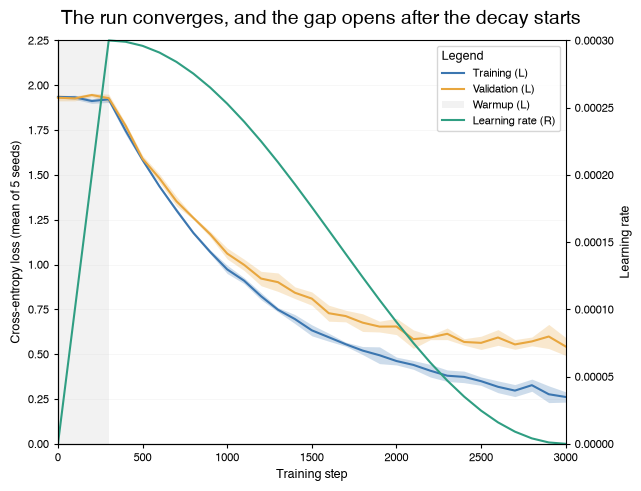

In [4]:
losses = LineChart(
    [training, validation],
    subtitle=["Training", "Validation"],
    show_yerr=True,
    # the steps the learning rate is still ramping up over
    vspans={"xmin": 0, "xmax": int(WARMUP_STEPS), "label": "Warmup"},
)

schedule = LineChart(
    [{"x": int(step), "y": float(rate)} for step, rate in zip(STEPS, learning_rate)],
    subtitle="Learning rate",
)

loss_figure = Panel(
    [
        {"figure": losses, "y_axis": "left"},
        {"figure": schedule, "y_axis": "right"},
    ],
    title="The run converges, and the gap opens after the decay starts",
    xlabel="Training step",
    ylabel_left="Cross-entropy loss (mean of 5 seeds)",
    ylabel_right="Learning rate",
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
loss_figure.show()

The band is the story: the seeds agree while the loss falls and start to disagree once the validation curve flattens, which is where the run stops being worth continuing.

### Which settings actually mattered?

A sweep leaves one row per trial and one column per setting, and the question is which columns the score depends on. [Parallel coordinates](../../how-to-guides/charts/parallelcoords/) puts one axis per column and one line per trial; coloring the lines by the objective with `hue` turns the chart into a map of where the good runs live. The learning rate is on a log scale, since the search sampled it that way and the raw values would otherwise pile up at the bottom of the axis.

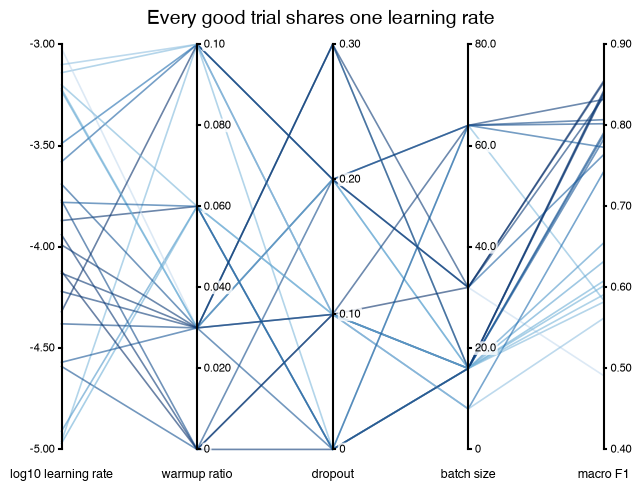

In [5]:
TRIAL_COLUMNS = ["log10 learning rate", "warmup ratio", "dropout", "batch size", "macro F1"]

trials = [
    {
        "log10 learning rate": round(float(rate), 2),
        "warmup ratio": float(warmup),
        "dropout": float(drop),
        "batch size": int(batch),
        "macro F1": round(float(score), 3),
    }
    for rate, warmup, drop, batch, score in zip(
        log_lr, warmup_ratio, dropout, batch_size, sweep_f1
    )
]

ParallelCoords(
    trials,
    title="Every good trial shares one learning rate",
    dimensions=TRIAL_COLUMNS,
    # the objective colors the lines, so the good region is visible at a glance
    hue="macro F1",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

Every line that ends near the top of the last axis passes through a learning rate between 10⁻⁴·³ and 10⁻³·⁹. On the other three axes those same lines cross freely, which is how the chart says a setting did not decide the outcome. To mute everything but the best trials instead of coloring them all, the guide's [emphasis rule](../../how-to-guides/charts/parallelcoords/#emphasis) does it with one argument.

## Evaluation

### Which classes does the model confuse?

A confusion matrix is a grid of counts, and a grid of counts is a [heatmap](../../how-to-guides/charts/heatmap/). Raw counts make the biggest class the brightest row whatever the model does, so the cells hold the share of each true class — every row sums to 1 — and the class sizes move into the row labels, where they belong. `z` is the grid, `x` and `y` are its labels, and `show_heatmap_values` writes each cell into the figure so the matrix reads as a table too.

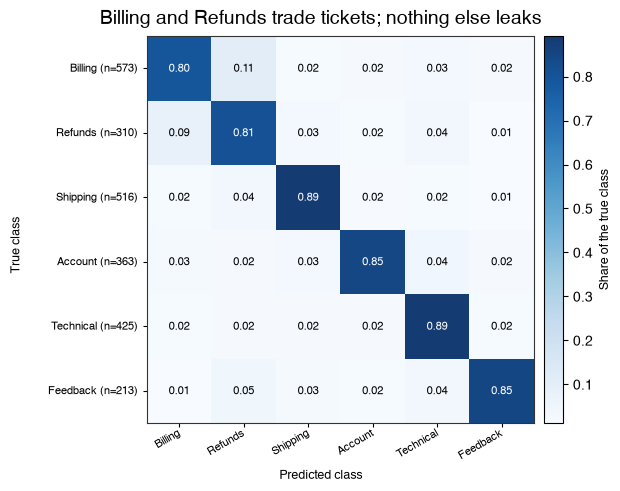

In [6]:
row_labels = [
    f"{name} (n={int(total)})"
    for name, total in zip(CLASSES, confusion_counts.sum(axis=1))
]

confusion_figure = Heatmap(
    {"x": CLASSES, "y": row_labels, "z": confusion_share.tolist()},
    title="Billing and Refunds trade tickets; nothing else leaks",
    xlabel="Predicted class",
    ylabel="True class",
    show_heatmap_values=True,
    show_colorbars=True,
    valfmt=VALUE_FORMAT.DECIMAL_2,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    xtickrotate=30,
    colorbar={"label": "Share of the true class"},
    figsize=FIG_SIZE.FULL_MEDIUM,
)
confusion_figure.show()

### How does the model trade precision for recall?

Both curves sweep the decision threshold, so both are line charts over a derived pair of arrays. What makes them readable is the reference line each needs: a ROC curve is read against chance, which is the diagonal, and a precision-recall curve is read against the share of positives, which is a horizontal line. `dlines` draws the first and `hlines` the second, so neither has to be faked with an extra data series. The two go side by side in a [Grid](../../how-to-guides/utility/grid/), since they answer one question together; both are [line charts](../../how-to-guides/charts/linechart/) over a pair of arrays.

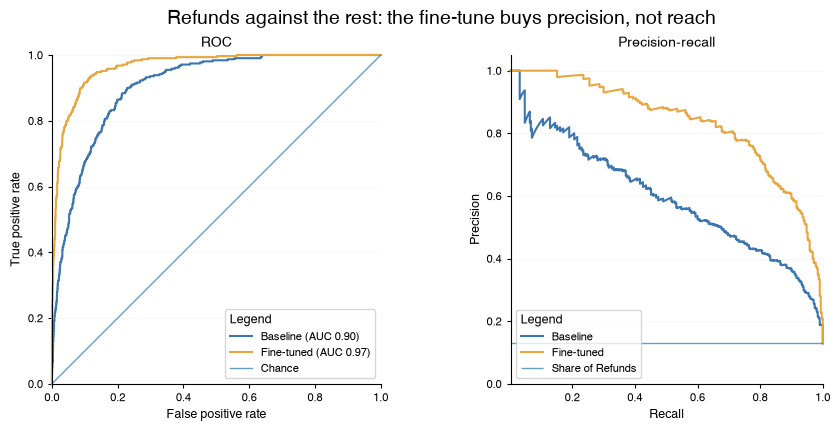

In [7]:
def as_points(xs, ys):
    return [{"x": float(x), "y": float(y)} for x, y in zip(xs, ys)]


roc = LineChart(
    [as_points(*roc_baseline), as_points(*roc_tuned)],
    title="ROC",
    xlabel="False positive rate",
    ylabel="True positive rate",
    subtitle=[f"Baseline (AUC {auc_baseline:.2f})", f"Fine-tuned (AUC {auc_tuned:.2f})"],
    # the diagonal a coin flip would draw
    dlines={"slope": 1, "intercept": 0, "label": "Chance"},
    show_legend=True,
    aspect_ratio=ASPECT_RATIO.EQUAL,
)

precision_recall = LineChart(
    [as_points(*pr_baseline), as_points(*pr_tuned)],
    title="Precision-recall",
    xlabel="Recall",
    ylabel="Precision",
    subtitle=["Baseline", "Fine-tuned"],
    # a threshold-free classifier lands on the share of positives
    hlines={"y": float(is_refund.mean()), "label": "Share of Refunds"},
    show_legend=True,
    ymin=0,
    ymax=1.05,
    aspect_ratio=ASPECT_RATIO.EQUAL,
)

Grid(
    [roc, precision_recall],
    title="Refunds against the rest: the fine-tune buys precision, not reach",
    figsize=(9.0, 4.2),
).show()

Both ROC curves hug the top left, which is what ROC does on an uncommon class: it rewards the model for the true negatives it gets for free. The precision-recall pair, read against the 13% of tickets that really are refunds, is the one to quote — at 80% recall the baseline is right about half the time and the fine-tuned model three times in four.

### Can the model's confidence be trusted?

A reliability diagram bins the predictions by the confidence the model reported and plots the accuracy it actually reached in each bin. The parity line is the answer key: on it, a 0.8 means 80% correct. It is a `dlines` diagonal again. The curve alone is misleading, though, because the bins hold wildly different numbers of predictions, so it sits over a [histogram](../../how-to-guides/charts/histogram/) of the confidences in the same `Grid`, with the two sharing the x-axis.

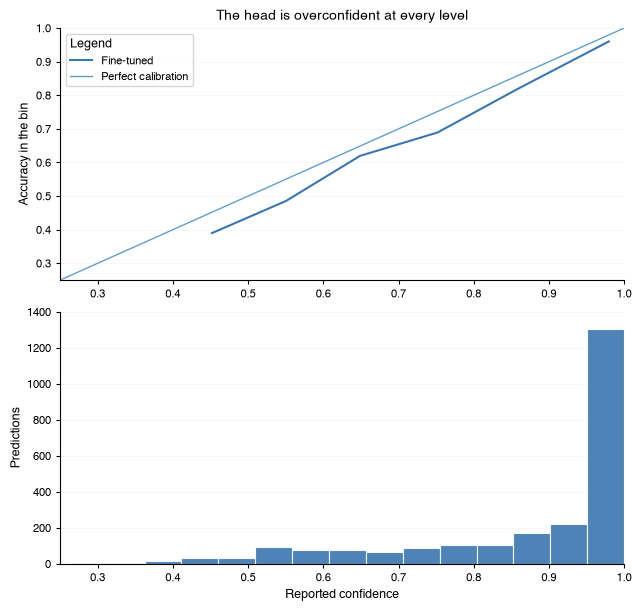

In [8]:
reliability = LineChart(
    [{"x": conf, "y": accuracy} for conf, accuracy, _ in calibration],
    title="The head is overconfident at every level",
    ylabel="Accuracy in the bin",
    subtitle="Fine-tuned",
    # perfect calibration: reported confidence equals observed accuracy
    dlines={"slope": 1, "intercept": 0, "label": "Perfect calibration"},
    show_legend=True,
    xmin=0.25,
    xmax=1.0,
    ymin=0.25,
    ymax=1.0,
)

confidences = Histogram(
    [{"x": float(value)} for value in confidence],
    xlabel="Reported confidence",
    ylabel="Predictions",
    num_bins=15,
    xmin=0.25,
    xmax=1.0,
)

calibration_figure = Grid(
    [[reliability], [confidences]],
    figsize=(6.3, 6.0),
    sharex=True,
)
calibration_figure.show()

Every point sits below the parity line, and the histogram says where that matters: most predictions land in the top bin, so the small gap there costs more than the large gap on the left. That is the figure that justifies temperature scaling before the model ships.

### Which classes did the fine-tune actually move?

A per-class score table is a [bar chart](../../how-to-guides/charts/barchart/) with the classes on the long axis, which means horizontal bars and `sort` so the order carries information. The point of the figure is not the level but the change, so each record carries its own `emphasis` role: the two classes the fine-tune moved by more than five points are highlighted, the rest are pushed to the background.

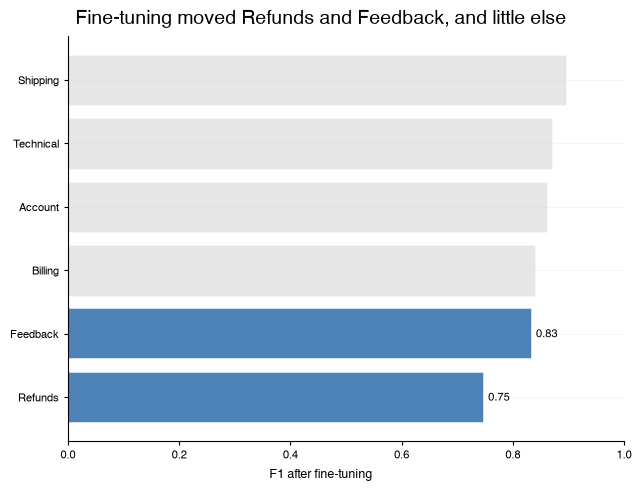

In [9]:
f1_records = [
    {
        "label": name,
        "y": round(float(score), 3),
        "emphasis": "highlight" if abs(change) > 0.05 else "background",
    }
    for name, score, change in zip(CLASSES, tuned_f1, tuned_f1 - baseline_f1)
]

BarChart(
    f1_records,
    title="Fine-tuning moved Refunds and Feedback, and little else",
    xlabel="F1 after fine-tuning",
    orientation="horizontal",
    sort="ascending",
    show_values=True,
    value_format=VALUE_FORMAT.DECIMAL_2,
    xmax=1.0,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Which features carry the decision?

Permutation importance produces the same shape — one label, one number — so it is the same [bar chart](../../how-to-guides/charts/barchart/), and the two figures read as a pair in a report. The table here is written out rather than simulated, as the output of such a run usually is.

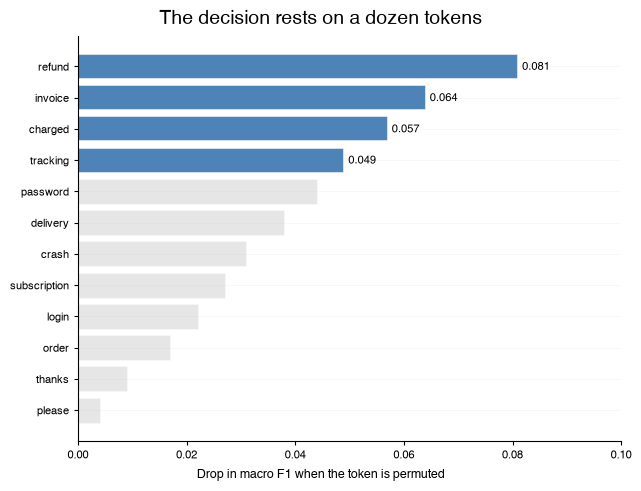

In [10]:
# the drop in macro F1 when the token is shuffled out of the input
IMPORTANCE = [
    ("refund", 0.081), ("invoice", 0.064), ("charged", 0.057), ("tracking", 0.049),
    ("password", 0.044), ("delivery", 0.038), ("crash", 0.031), ("subscription", 0.027),
    ("login", 0.022), ("order", 0.017), ("thanks", 0.009), ("please", 0.004),
]

BarChart(
    [{"label": token, "y": drop} for token, drop in IMPORTANCE],
    title="The decision rests on a dozen tokens",
    xlabel="Drop in macro F1 when the token is permuted",
    orientation="horizontal",
    sort="ascending",
    show_values=True,
    value_format=VALUE_FORMAT.DECIMAL_3,
    emphasis_rule={"top": 4},
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Comparison with published models

The three figures below are the only ones on this page drawn from real numbers. They come from two published tables: the base-model evaluations in the [Qwen2.5 LLM blog post](https://qwenlm.github.io/blog/qwen2.5-llm/) (Qwen Team, September 2024) and the instruction-tuned table of the [Llama 3.1 8B model card](https://huggingface.co/meta-llama/Llama-3.1-8B) (Meta, July 2024).

### Where does each model rank, benchmark by benchmark?

A leaderboard is usually read as one number per model, which hides the thing worth knowing: whether the order holds from one benchmark to the next. A [bump chart](../../how-to-guides/charts/bumpchart/) ranks the models within each benchmark and joins each model's ranks, so a crossing is a model that is good at one kind of task and not another. The scores go in as `y` and the chart does the ranking.

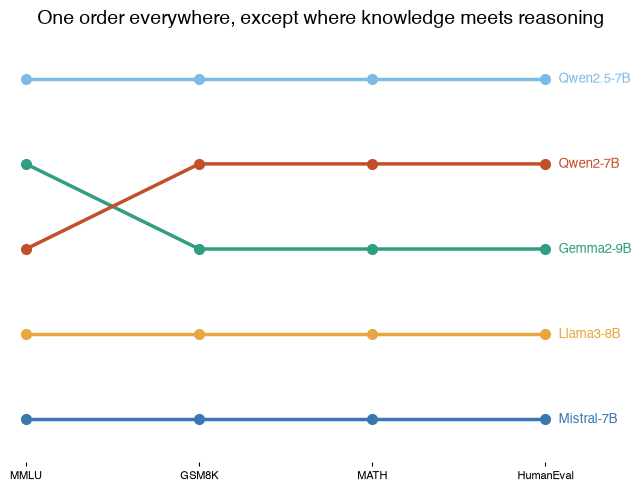

In [11]:
BENCHMARKS = ["MMLU", "GSM8K", "MATH", "HumanEval"]

# base models, Qwen2.5 LLM blog post (Qwen Team, September 2024)
PUBLISHED = {
    "Mistral-7B": [64.2, 36.2, 10.2, 29.3],
    "Llama3-8B": [66.6, 55.3, 20.5, 33.5],
    "Gemma2-9B": [71.3, 70.7, 37.7, 37.8],
    "Qwen2-7B": [70.3, 80.2, 43.5, 51.2],
    "Qwen2.5-7B": [74.2, 85.4, 49.8, 57.9],
}

leaderboard_figure = BumpChart(
    [
        [{"x": position, "y": score} for position, score in enumerate(scores)]
        for scores in PUBLISHED.values()
    ],
    title="One order everywhere, except where knowledge meets reasoning",
    subtitle=list(PUBLISHED),
    xticks=list(range(len(BENCHMARKS))),
    xticklabels=BENCHMARKS,
    label_position="end",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
leaderboard_figure.show()

Only one pair crosses: Gemma2-9B leads Qwen2-7B on MMLU, the knowledge benchmark, and trails it on the three that ask for reasoning or code. Everything else keeps its place, which is itself the finding — a single average would have said as much with less work, and would have hidden the one exception.

### What did a round of post-training change?

Before and after is two numbers per row, which is what a [dumbbell chart](../../how-to-guides/charts/dumbbellchart/) draws: a dot for each, joined by the line whose length is the change. Sorting by `delta` puts the benchmarks that moved at the top, and `show_values="delta"` writes the change rather than the endpoints, since the endpoints are already on the axis.

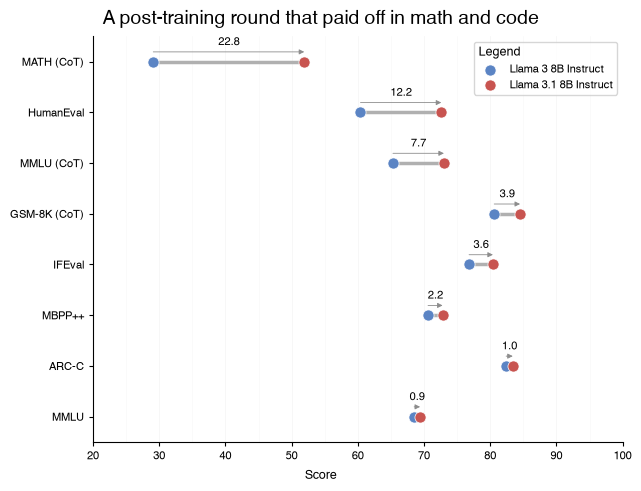

In [12]:
# Llama 3 8B Instruct -> Llama 3.1 8B Instruct, from the Llama 3.1 8B model card
POST_TRAINING = [
    ("MATH (CoT)", 29.1, 51.9),
    ("HumanEval", 60.4, 72.6),
    ("MMLU (CoT)", 65.3, 73.0),
    ("GSM-8K (CoT)", 80.6, 84.5),
    ("IFEval", 76.8, 80.4),
    ("MBPP++", 70.6, 72.8),
    ("MMLU", 68.5, 69.4),
    ("ARC-C", 82.4, 83.4),
]

DumbbellChart(
    [{"label": name, "start": before, "end": after} for name, before, after in POST_TRAINING],
    title="A post-training round that paid off in math and code",
    xlabel="Score",
    start_name="Llama 3 8B Instruct",
    end_name="Llama 3.1 8B Instruct",
    sort="descending",
    sort_by="delta",
    show_values="delta",
    show_direction=True,
    show_legend=True,
    value_format=VALUE_FORMAT.DECIMAL,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### How big is the benchmark's own error bar?

A leaderboard gap of two points means nothing until it is read against the benchmark's size. Each score is a proportion over a fixed test set, so it carries a binomial interval: ±1.96·√(p(1−p)/n). HumanEval has 164 problems and MMLU 14,042 questions, which is a difference of a factor of ten in the error bar. A [scatter chart](../../how-to-guides/charts/scatterchart/) takes the interval per point as `yerr` and draws it with `show_yerr=True`, so the reader sees the uncertainty instead of being asked to remember it.

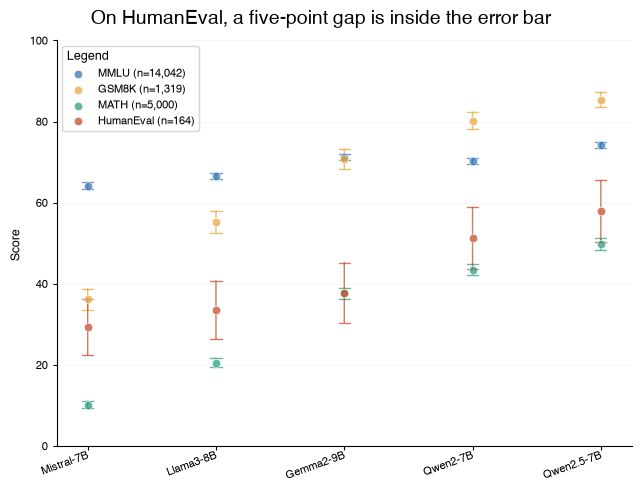

In [13]:
# the number of items in each benchmark's test set
BENCHMARK_SIZE = {"MMLU": 14042, "GSM8K": 1319, "MATH": 5000, "HumanEval": 164}


def wald_interval(score, size):
    """The half-width of the 95% interval around a score in percent."""
    share = score / 100
    return 100 * 1.96 * (share * (1 - share) / size) ** 0.5


benchmark_series = [
    [
        {
            "x": position,
            "y": PUBLISHED[model][column],
            "yerr": round(
                wald_interval(PUBLISHED[model][column], BENCHMARK_SIZE[name]), 2
            ),
        }
        for position, model in enumerate(PUBLISHED)
    ]
    for column, name in enumerate(BENCHMARKS)
]

ScatterChart(
    benchmark_series,
    title="On HumanEval, a five-point gap is inside the error bar",
    ylabel="Score",
    subtitle=[f"{name} (n={BENCHMARK_SIZE[name]:,})" for name in BENCHMARKS],
    show_yerr=True,
    show_legend=True,
    xticks=list(range(len(PUBLISHED))),
    xticklabels=list(PUBLISHED),
    xtickrotate=20,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The MMLU bars are shorter than the markers; the HumanEval bars reach about eight points either way, so the Gemma2-9B and Llama3-8B scores on that benchmark are not distinguishable at all. This interval is the optimistic one — it counts only the sampling of the test set, not the prompt, the decoding, or the seed.

## The corpus behind the model

### How long are the documents, and did the splits stay comparable?

One distribution per split, stacked so the shapes can be compared, is a [ridgeline plot](../../how-to-guides/charts/ridgelineplot/): each record is a `label` and a `value`, and the chart estimates the density per label. It answers a question a summary table cannot — whether the splits were drawn from the same population.

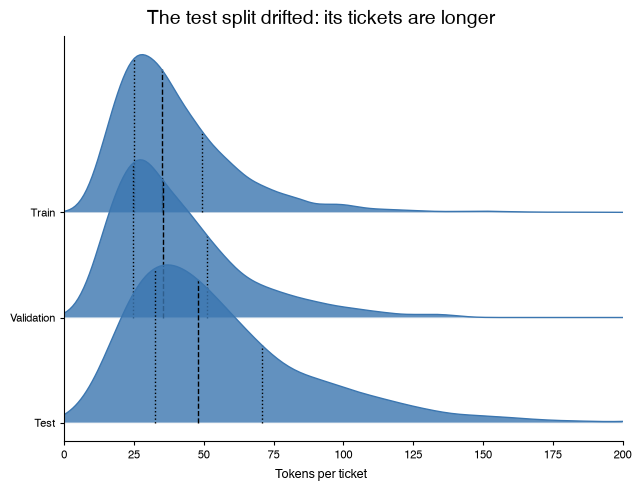

In [14]:
lengths = [
    {"label": split, "value": float(length)}
    for split in SPLITS
    for length in token_lengths[split]
]

RidgelinePlot(
    lengths,
    title="The test split drifted: its tickets are longer",
    xlabel="Tokens per ticket",
    inner="quartiles",
    xmin=0,
    xmax=200,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

Train and validation sit on top of each other, as they should — they were split at random. The test split was collected a quarter later and its whole distribution has moved right, which is worth a sentence in the report before any score from it is believed.

### Does the vocabulary behave?

Token frequency against rank is the standard sanity check on a corpus, and it is only readable on log-log axes, where Zipf's law is a straight line. The [line chart](../../how-to-guides/charts/linechart/) takes the scale of each axis in `scalex` and `scaley`, and a second series holding an exact 1/rank curve gives the eye something to judge the first against.

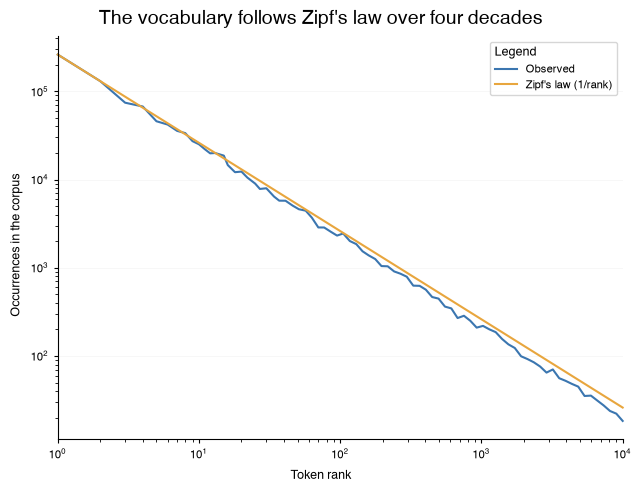

In [15]:
observed = [
    {"x": int(rank), "y": float(count)} for rank, count in zip(ZIPF_RANKS, zipf_counts)
]
# the law itself: the rth token appears 1/r as often as the first
ideal = [{"x": int(rank), "y": float(zipf_counts[0]) / int(rank)} for rank in ZIPF_RANKS]

LineChart(
    [observed, ideal],
    title="The vocabulary follows Zipf's law over four decades",
    xlabel="Token rank",
    ylabel="Occurrences in the corpus",
    subtitle=["Observed", "Zipf's law (1/rank)"],
    scalex="log",
    scaley="log",
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### What did filtering remove?

A filtering pipeline is a flow: a quantity enters, splits at each stage, and a fraction reaches the end. That is a [Sankey chart](../../how-to-guides/charts/sankeychart/), whose data is a list of links, each a `source`, a `target`, and a `value`. Naming the discarded branch at every stage is what turns a funnel into an auditable record.

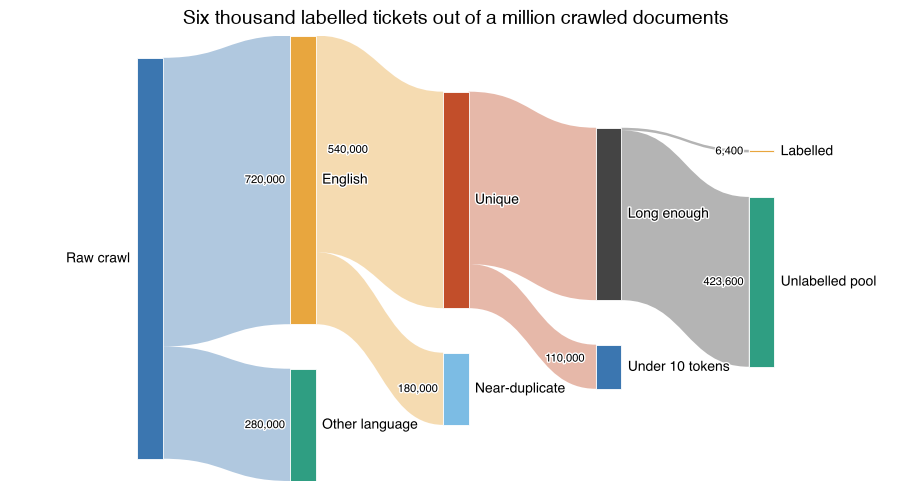

In [16]:
FILTERING = [
    {"source": "Raw crawl", "target": "English", "value": 720_000},
    {"source": "Raw crawl", "target": "Other language", "value": 280_000},
    {"source": "English", "target": "Unique", "value": 540_000},
    {"source": "English", "target": "Near-duplicate", "value": 180_000},
    {"source": "Unique", "target": "Long enough", "value": 430_000},
    {"source": "Unique", "target": "Under 10 tokens", "value": 110_000},
    {"source": "Long enough", "target": "Labelled", "value": 6_400},
    {"source": "Long enough", "target": "Unlabelled pool", "value": 423_600},
]

SankeyChart(
    {"links": FILTERING},
    title="Six thousand labelled tickets out of a million crawled documents",
    show_values=True,
    value_format=VALUE_FORMAT.THOUSANDS,
    figsize=(9.0, 4.8),
).show()

The last ribbon is a hairline, and that is the finding: labelling, not crawling, is what the corpus is short of. Four numbers in a paragraph never make that as obvious as a ribbon that disappears.

## The report figure

A paper or a model card rarely has room for thirteen figures. The four that carry the argument — the run converged, here is what it confuses, here is where it sits among published models, and here is how much its confidence is worth — go into one panel with [Grid](../../how-to-guides/utility/grid/), which takes the figures already drawn above and redraws them into its cells. Nested lists are the layout: one inner list per row.

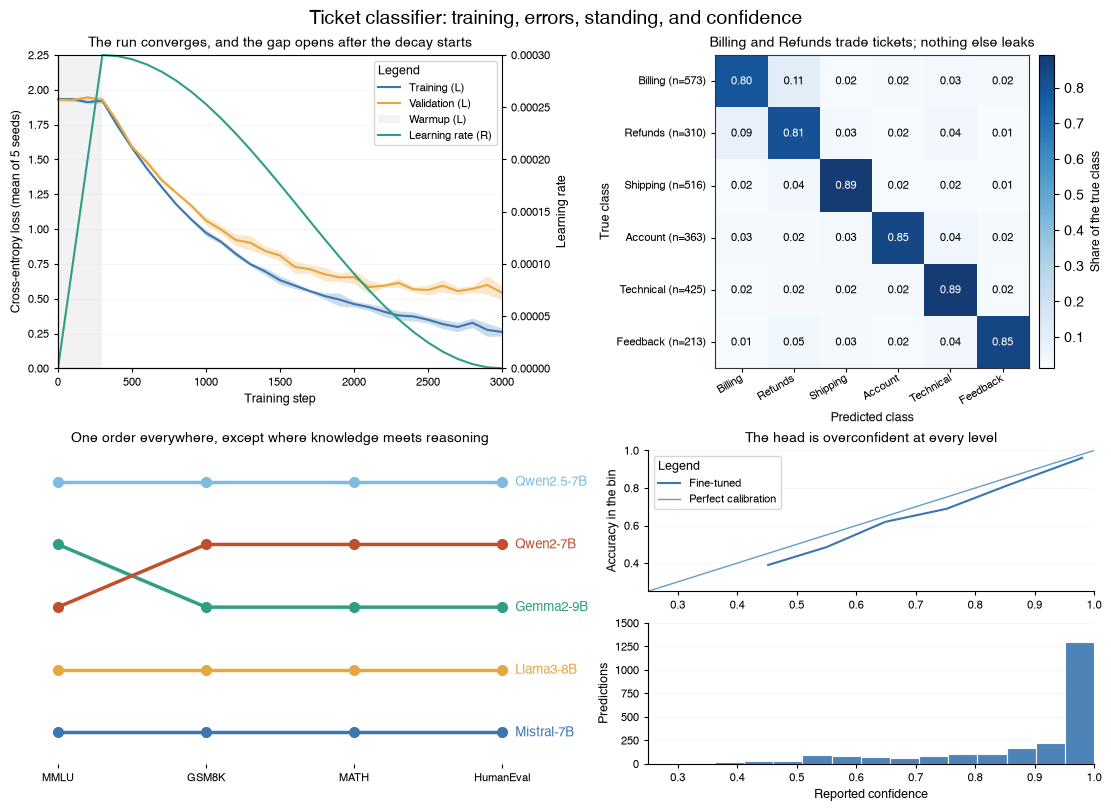

In [17]:
Grid(
    [
        [loss_figure, confusion_figure],
        [leaderboard_figure, calibration_figure],
    ],
    title="Ticket classifier: training, errors, standing, and confidence",
    figsize=(11.0, 8.0),
).show()

Every figure on this page is one call to a chart function over a list of dicts, so the way to adapt any of them is to open the guide it links to and read the parameter that does the job. The charts index lists them all: [Charts](../../how-to-guides/charts/).